In the previous notebook, we understood the basic structure of the PaySim dataset.

In this notebook, we will perform data quality checks, cleaning validation, and exploratory data analysis to understand fraud patterns before feature engineering and model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/raw/paysim_transactions.csv"

In [8]:
df = pd.read_csv(file_path, nrows=200000)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


The full dataset has more than 6 million rows, so we first use 200,000 rows for faster analysis.

In [9]:
df.shape

(200000, 11)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  str    
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  str    
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  str    
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 16.8 MB


In [11]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [12]:
# Missing value check using chunks to avoid memory issues
missing_values = pd.Series(dtype="int64")

for chunk in pd.read_csv(file_path, chunksize=500000):
    missing_values = missing_values.add(chunk.isnull().sum(), fill_value=0)

missing_values.astype(int)

amount            0
isFlaggedFraud    0
isFraud           0
nameDest          0
nameOrig          0
newbalanceDest    0
newbalanceOrig    0
oldbalanceDest    0
oldbalanceOrg     0
step              0
type              0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Validate Transaction Types
df["type"].unique()

<StringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str

In [15]:
df["type"].value_counts()

type
PAYMENT     73427
CASH_OUT    66488
CASH_IN     41579
TRANSFER    16836
DEBIT        1670
Name: count, dtype: int64

In [16]:
# Validate Transaction Types using chunks to avoid memory issues
type_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(file_path, usecols=["type"], chunksize=500000):
    type_counts = type_counts.add(chunk["type"].value_counts(), fill_value=0)

type_counts = type_counts.astype(int).sort_values(ascending=False)
type_counts

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
dtype: int64

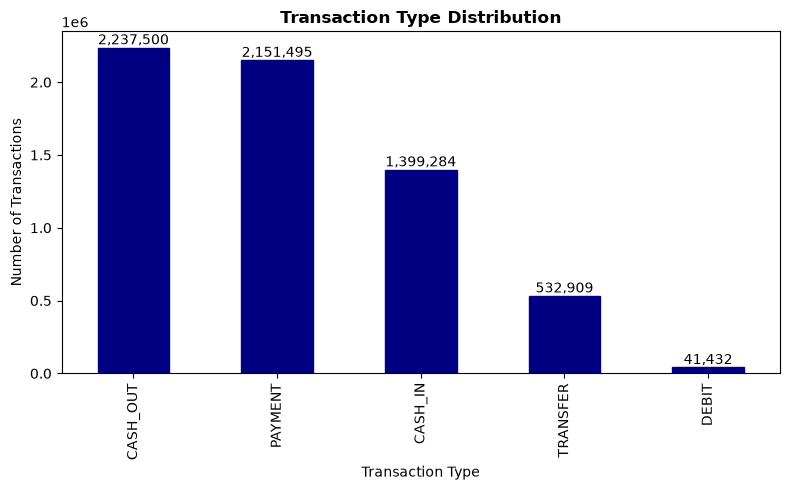

In [35]:
# Visualize Transaction Types
plt.figure(figsize=(8,5))
type_counts.plot(kind="bar", color="#000080", edgecolor="navy")
plt.title("Transaction Type Distribution", fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for i, v in enumerate(type_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [24]:
# Validate Fraudulent Transactions using chunks
fraud_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(file_path, usecols=["isFraud"], chunksize=500000):
    fraud_counts = fraud_counts.add(chunk["isFraud"].value_counts(), fill_value=0)

fraud_counts = fraud_counts.astype(int)
fraud_counts

isFraud
0    6354407
1       8213
dtype: int64

In [25]:
# Calculate Fraud Rate
fraud_rate = fraud_counts[1] / fraud_counts.sum() * 100
print(f"Fraud Rate: {fraud_rate:.4f}%")

Fraud Rate: 0.1291%


This tells us how rare fraud transactions are. Since fraud is very rare, this is an imbalanced classification problem.

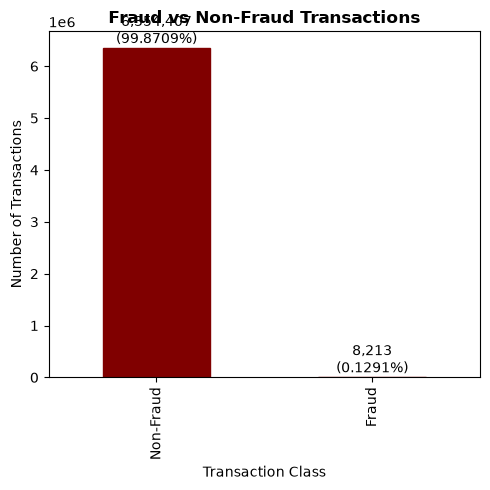

In [40]:
# Visualize Fraudulent Transactions
fraud_counts.index = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(5,5))
fraud_counts.plot(kind="bar", color=["#800000", "#E15759"], edgecolor="maroon")
plt.title("Fraud vs Non-Fraud Transactions", fontweight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for i, v in enumerate(fraud_counts.values):
    plt.text(i, v, f"{v:,}\n({v / fraud_counts.sum() * 100:.4f}%)", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [41]:
# Validate Fraudulent Transactions by Type using chunks
type_fraud = pd.DataFrame()

for chunk in pd.read_csv(file_path, usecols=["type", "isFraud"], chunksize=500000):
    temp = pd.crosstab(chunk["type"], chunk["isFraud"])
    type_fraud = type_fraud.add(temp, fill_value=0)

type_fraud = type_fraud.rename(columns={0: "Non-Fraud", 1: "Fraud"}).astype(int)
type_fraud

isFraud,Non-Fraud,Fraud
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


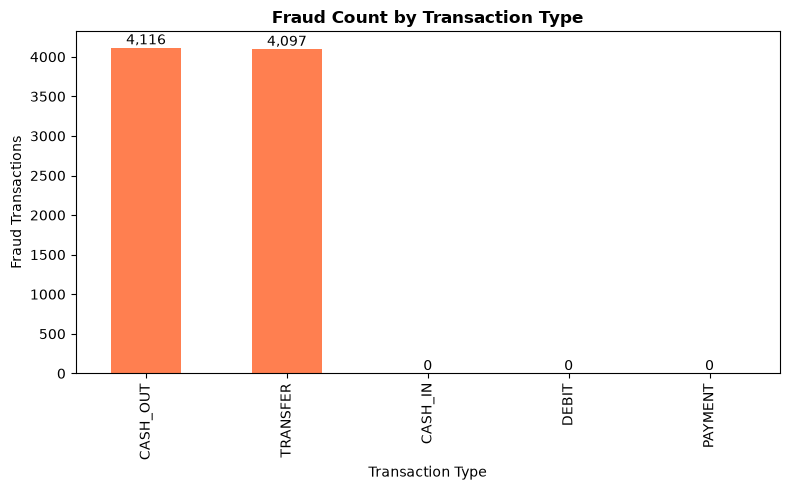

In [49]:
# Visualize Fraudulent Transactions by Type
fraud_by_type = type_fraud["Fraud"].sort_values(ascending=False)

plt.figure(figsize=(8,5))
fraud_by_type.plot(kind="bar", color="#FF7F50")
plt.title("Fraud Count by Transaction Type", fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Transactions")

for i, v in enumerate(fraud_by_type.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [43]:
# Calculate Fraud Rate by Transaction Type
type_fraud["Fraud_Rate_%"] = type_fraud["Fraud"] / (type_fraud["Non-Fraud"] + type_fraud["Fraud"]) * 100
type_fraud.sort_values("Fraud_Rate_%", ascending=False)

isFraud,Non-Fraud,Fraud,Fraud_Rate_%
type,,,
TRANSFER,528812,4097,0.768799
CASH_OUT,2233384,4116,0.183955
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


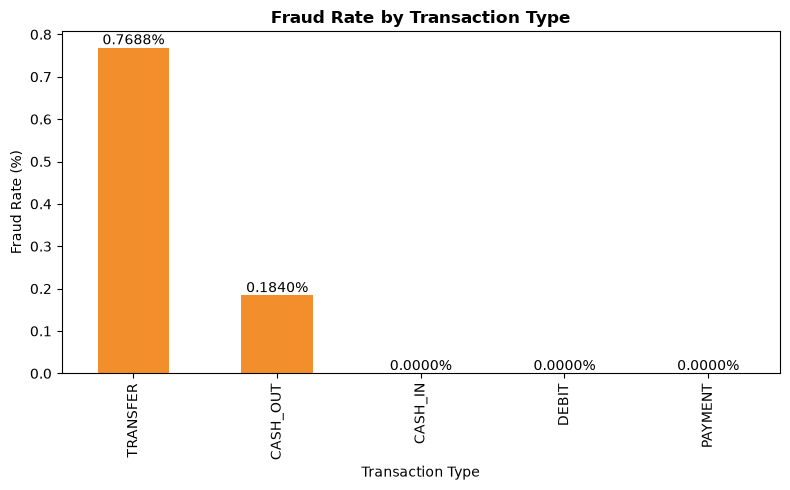

In [44]:
# Visualize Fraud Rate by Transaction Type
fraud_rate_type = type_fraud["Fraud_Rate_%"].sort_values(ascending=False)

plt.figure(figsize=(8,5))
fraud_rate_type.plot(kind="bar", color="#F28E2B")
plt.title("Fraud Rate by Transaction Type", fontweight="bold")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

for i, v in enumerate(fraud_rate_type.values):
    plt.text(i, v, f"{v:.4f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [45]:
# Validate Transaction Amounts (Statistics)
df["amount"].describe()

count    2.000000e+05
mean     1.808112e+05
std      3.291800e+05
min      3.200000e-01
25%      1.201612e+04
50%      6.872104e+04
75%      2.290791e+05
max      1.000000e+07
Name: amount, dtype: float64

In [46]:
# Validate Transaction Amounts by Fraudulent Transactions (Statistics)
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,199853.0,180476.435230,3.264875e+05,0.32,12015.01,68726.58,229040.46,6419835.27
1,147.0,635893.197211,1.522142e+06,164.00,13707.11,43092.00,361559.69,10000000.00


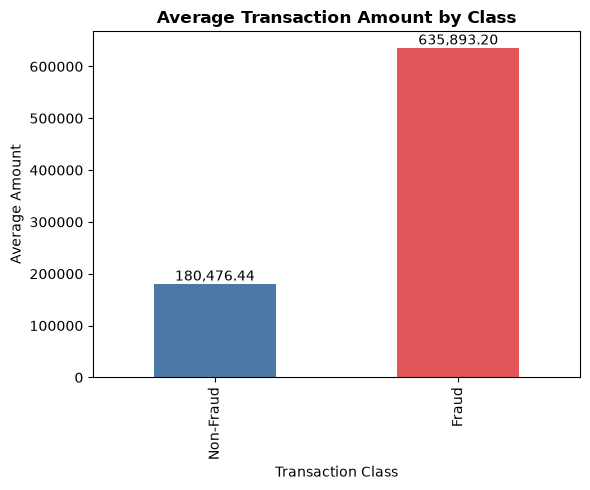

In [47]:
# Visualize Average Transaction Amount by Class
avg_amount = df.groupby("isFraud")["amount"].mean()
avg_amount.index = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(6,5))
avg_amount.plot(kind="bar", color=["#4C78A8", "#E15759"])
plt.title("Average Transaction Amount by Class", fontweight="bold")
plt.xlabel("Transaction Class")
plt.ylabel("Average Amount")

for i, v in enumerate(avg_amount.values):
    plt.text(i, v, f"{v:,.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [50]:
# Validate Balance Columns (Statistics)
balance_cols = ["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
df[balance_cols].describe()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05
mean,8.821957e+05,9.001938e+05,9.411592e+05,1.191866e+06
std,2.766264e+06,2.803759e+06,2.373010e+06,2.655236e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.951000e+04,0.000000e+00,5.055850e+04,1.320839e+05
75%,1.915686e+05,2.275212e+05,7.645361e+05,1.189164e+06
max,3.893942e+07,3.894623e+07,3.903958e+07,3.904248e+07


These columns are important because fraud may create abnormal balance changes.

In [51]:
# Validate Balance Differences
df["origin_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["destination_balance_diff"] = df["newbalanceDest"] - df["oldbalanceDest"]

df[["amount", "origin_balance_diff", "destination_balance_diff"]].head()

,amount,origin_balance_diff,destination_balance_diff
0,9839.64,9839.64,0.0
1,1864.28,1864.28,0.0
2,181.00,181.00,0.0
3,181.00,181.00,-21182.0
4,11668.14,11668.14,0.0


In [52]:
# Analyze isFlaggedFraud
flagged_fraud = pd.DataFrame()

for chunk in pd.read_csv(file_path, usecols=["isFraud", "isFlaggedFraud"], chunksize=500000):
    temp = pd.crosstab(chunk["isFraud"], chunk["isFlaggedFraud"])
    flagged_fraud = flagged_fraud.add(temp, fill_value=0)

flagged_fraud.astype(int)

isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


`isFlaggedFraud` is the original system-generated fraud flag. We compare it with isFraud to check whether it actually catches fraud properly.

In [53]:
# Validate Origin and Destination Prefixes
df["origin_prefix"] = df["nameOrig"].str[0]
df["dest_prefix"] = df["nameDest"].str[0]

df[["origin_prefix", "dest_prefix"]].value_counts()

origin_prefix  dest_prefix
C              C              126573
               M               73427
Name: count, dtype: int64

`c` usually represents customer accounts and `M` represents merchant accounts. This can help in feature engineering later.

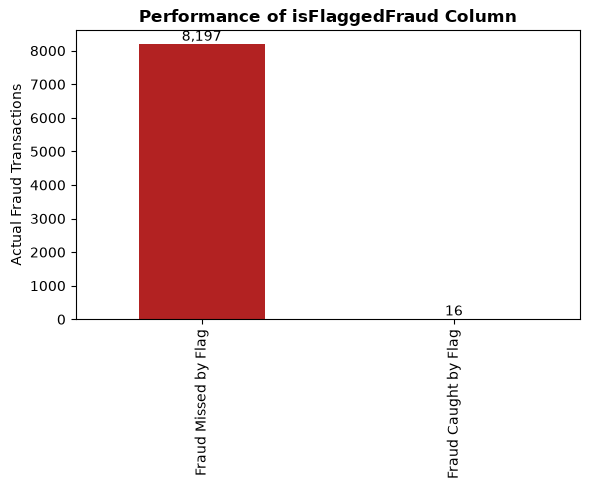

In [55]:
# Analyze Flagged Fraud Performance
flagged_performance = pd.Series({
    "Fraud Missed by Flag": 8197,
    "Fraud Caught by Flag": 16
})

plt.figure(figsize=(6,5))
flagged_performance.plot(kind="bar", color=["#B22222", "#2E8B57"])
plt.title("Performance of isFlaggedFraud Column", fontweight="bold")
plt.ylabel("Actual Fraud Transactions")

for i, v in enumerate(flagged_performance.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Final Summary

In this notebook, we performed data quality validation and exploratory analysis on the PaySim fraud detection dataset.

The raw dataset is already stored locally in `data/raw/paysim_transactions.csv`. Since the file has more than 6 million rows, we used a 200,000-row sample for quick analysis and used **chunk** processing for full-dataset checks such as missing values, transaction type counts, fraud counts, and `isFlaggedFraud` analysis.

### Data Quality Checks

- The dataset contains **11 columns**.
- The target variable is **`isFraud`**.
- No missing values were found in the full dataset.
- No duplicate rows were found in the 200,000-row sample.
- The available transaction types are `CASH_OUT`, `PAYMENT`, `CASH_IN`, `TRANSFER`, and `DEBIT`.
- No row deletion or major cleaning was required at this stage.

### Fraud Distribution

The full dataset contains:

- **6,354,407 non-fraud transactions**
- **8,213 fraud transactions**
- Fraud rate: **0.1291%**

This confirms that the dataset is highly imbalanced. Because of this, accuracy alone will not be enough for model evaluation. Recall, precision, F1-score, confusion matrix, and false negatives will be more important.

### Transaction Type Insights

Fraud appears only in:

- `CASH_OUT`: **4,116 fraud transactions**
- `TRANSFER`: **4,097 fraud transactions**

No fraud cases were found in `PAYMENT`, `CASH_IN`, or `DEBIT`.

Fraud rate by transaction type:

- `TRANSFER`: **0.7688%**
- `CASH_OUT`: **0.1840%**
- Other transaction types: **0%**

This shows that `type` is an important feature for fraud detection.

### Amount and Balance Insights

Fraud transactions have a higher average transaction amount than non-fraud transactions.

- Average non-fraud amount: **180,476.44**
- Average fraud amount: **635,893.20**

The balance columns are also important because fraud may create abnormal balance movement. I created temporary balance-difference checks:

- `origin_balance_diff = oldbalanceOrg - newbalanceOrig`
- `destination_balance_diff = newbalanceDest - oldbalanceDest`

These checks are useful for understanding balance behavior and will help in feature engineering.

### isFlaggedFraud Insight

The `isFlaggedFraud` column is the original system-generated fraud flag, but it is not reliable enough to detect fraud properly.

From the full dataset:

- Actual fraud cases: **8,213**
- Fraud cases flagged by `isFlaggedFraud`: **16**
- Fraud cases missed by `isFlaggedFraud`: **8,197**

So, `isFraud` will remain the actual target variable. `isFlaggedFraud` can be kept for analysis, but it should not be treated as the main fraud label.

### Final Cleaning Decision

No final cleaned dataset was saved in this notebook because no missing values, invalid transaction types, or major cleaning issues were found.

This notebook mainly confirms that the raw data is usable and ready for feature engineering. The final processed dataset will be saved after creating model-ready features such as transaction ID, encoded transaction type, account-type indicators, balance-difference features, and amount-ratio features.